In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df=pd.read_csv("Bank Customer Churn Prediction.csv")

In [3]:
df.head(4)

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0


In [4]:
df.shape

(10000, 12)

In [5]:
df.info

<bound method DataFrame.info of       customer_id  credit_score  country  gender  age  tenure    balance  \
0        15634602           619   France  Female   42       2       0.00   
1        15647311           608    Spain  Female   41       1   83807.86   
2        15619304           502   France  Female   42       8  159660.80   
3        15701354           699   France  Female   39       1       0.00   
4        15737888           850    Spain  Female   43       2  125510.82   
...           ...           ...      ...     ...  ...     ...        ...   
9995     15606229           771   France    Male   39       5       0.00   
9996     15569892           516   France    Male   35      10   57369.61   
9997     15584532           709   France  Female   36       7       0.00   
9998     15682355           772  Germany    Male   42       3   75075.31   
9999     15628319           792   France  Female   28       4  130142.79   

      products_number  credit_card  active_member  esti

In [6]:
df.isnull().sum()

customer_id         0
credit_score        0
country             0
gender              0
age                 0
tenure              0
balance             0
products_number     0
credit_card         0
active_member       0
estimated_salary    0
churn               0
dtype: int64

In [7]:
df.describe()

,customer_id,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [8]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
9995    False
9996    False
9997    False
9998    False
9999    False
Length: 10000, dtype: bool

In [9]:
df = df.drop(columns=["customer_id"])

In [10]:
df

,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


# A. Distribution of Numerical Features

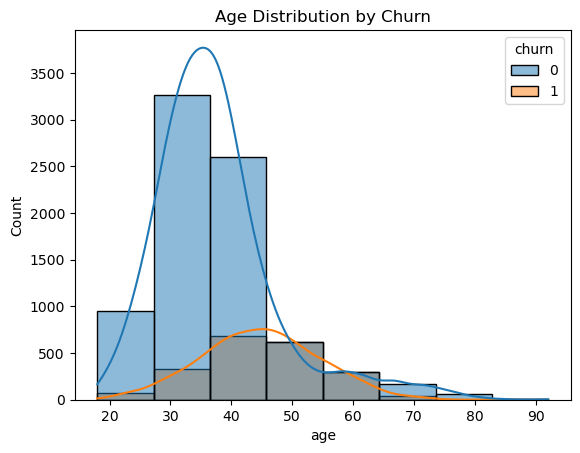

In [11]:
sns.histplot(data=df, x="age", hue="churn", bins=8, kde=True)

plt.title("Age Distribution by Churn")
plt.show()

<Axes: xlabel='age', ylabel='Density'>

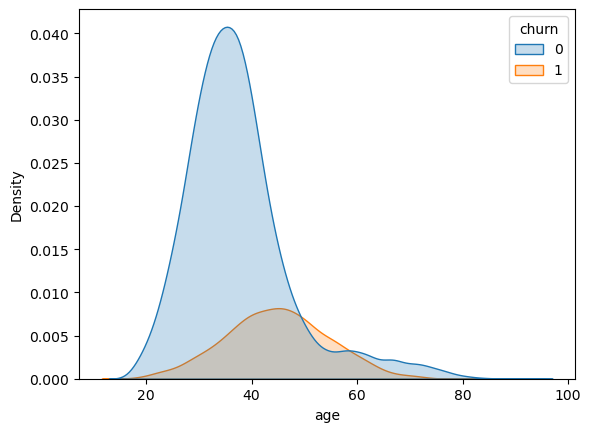

In [12]:
sns.kdeplot(data=df, x="age", hue="churn", fill=True)

<Axes: xlabel='age', ylabel='Count'>

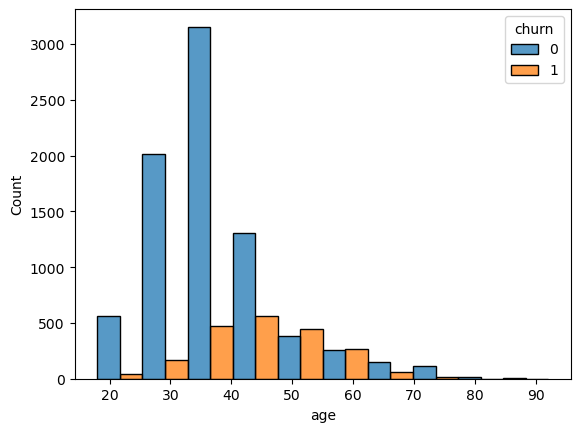

In [13]:
sns.histplot(data=df, x="age", hue="churn", bins=10, multiple="dodge")

# balance vs churn

<Axes: xlabel='balance', ylabel='Count'>

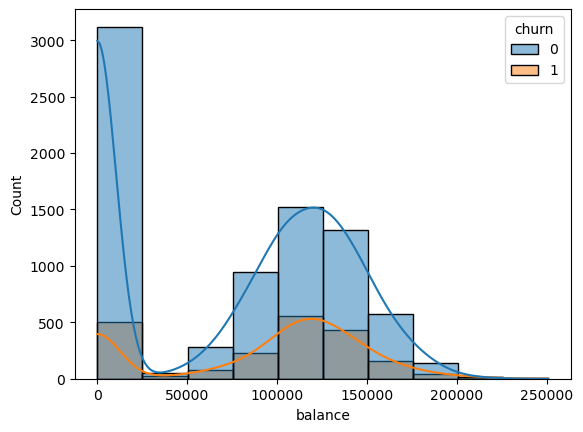

In [14]:
sns.histplot(data=df,x='balance',hue='churn', bins=10 ,kde=True)

<Axes: xlabel='balance', ylabel='Count'>

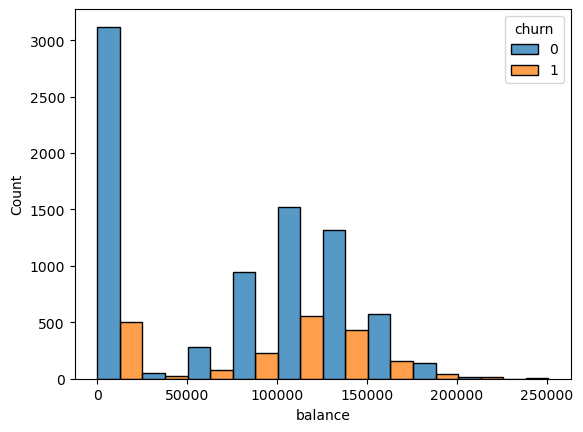

In [15]:
sns.histplot(data=df, x="balance", hue="churn", bins=10, multiple="dodge")

<Axes: xlabel='balance', ylabel='Density'>

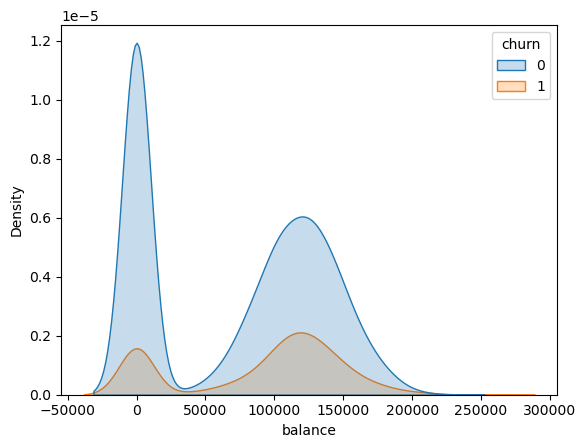

In [16]:
sns.kdeplot(x='balance', hue='churn', data=df,fill=True)

# estimated_salary vs churn

<Axes: xlabel='estimated_salary', ylabel='Count'>

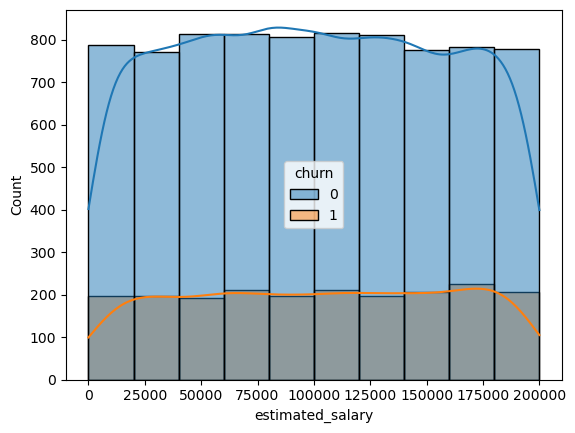

In [17]:
sns.histplot(data=df,x='estimated_salary', hue='churn' ,bins=10, kde=True)

<Axes: xlabel='balance', ylabel='Density'>

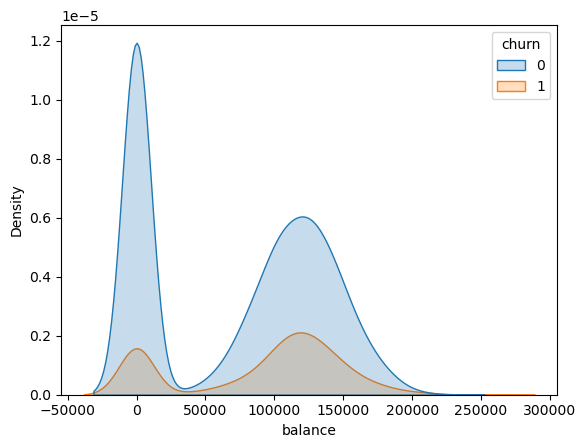

In [18]:
sns.kdeplot(x='balance', hue='churn', data=df,fill=True)

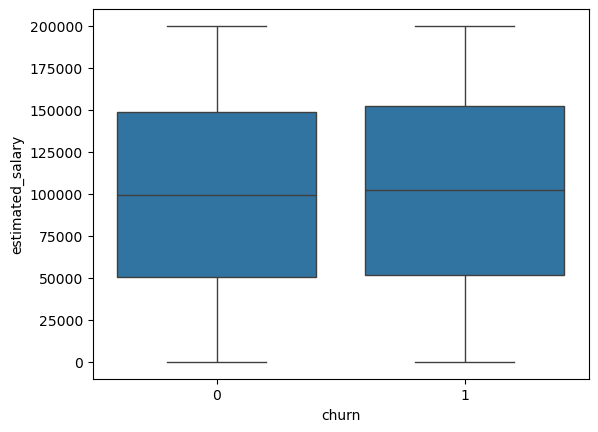

In [19]:
sns.boxplot(x='churn', y='estimated_salary', data=df)
plt.show()

In [20]:
df['balance']

0            0.00
1        83807.86
2       159660.80
3            0.00
4       125510.82
          ...    
9995         0.00
9996     57369.61
9997         0.00
9998     75075.31
9999    130142.79
Name: balance, Length: 10000, dtype: float64

# B. Categorical Features vs Churn

# Age vs churn

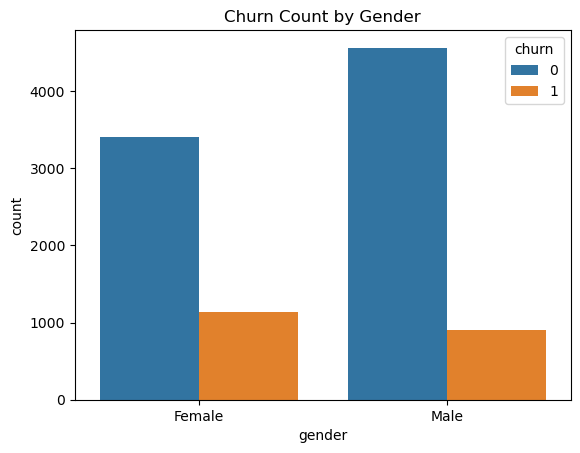

In [21]:
sns.countplot(data=df, x="gender", hue='churn' )

plt.title("Churn Count by Gender")
plt.show()

In [22]:
import pandas as pd

pd.crosstab(df["gender"], df["churn"], normalize="index")

churn,0,1
gender,,
Female,0.749285,0.250715
Male,0.835441,0.164559


In [23]:
df = pd.get_dummies(df, columns=[ 'gender'], drop_first=True)
df.head(3)

,credit_score,country,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn,gender_Male
0,619,France,42,2,0.00,1,1,1,101348.88,1,False
1,608,Spain,41,1,83807.86,1,0,1,112542.58,0,False
2,502,France,42,8,159660.80,3,1,0,113931.57,1,False


<Axes: xlabel='churn', ylabel='age'>

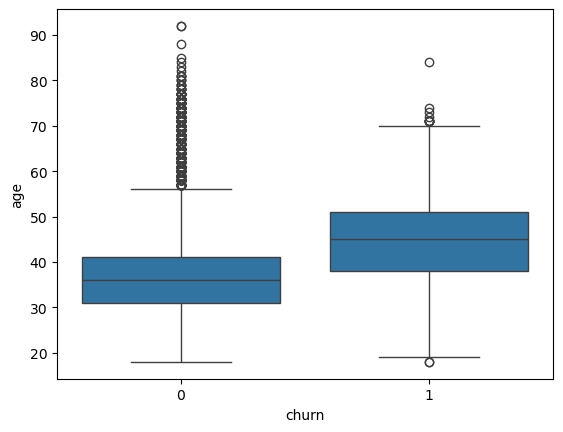

In [24]:
sns.boxplot(data=df,x='churn',y='age')

# feature engineering

In [25]:
df['age_group'] = pd.cut(df['age'],
                        bins=[18,30,45,60,100],
                        labels=['Young','Adult','MidAge','Senior'])

In [26]:
df = pd.get_dummies(df, columns=['age_group'], drop_first=True)

In [27]:
df

,credit_score,country,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn,gender_Male,age_group_Adult,age_group_MidAge,age_group_Senior
0,619,France,42,2,0.00,1,1,1,101348.88,1,False,True,False,False
1,608,Spain,41,1,83807.86,1,0,1,112542.58,0,False,True,False,False
2,502,France,42,8,159660.80,3,1,0,113931.57,1,False,True,False,False
3,699,France,39,1,0.00,2,0,0,93826.63,0,False,True,False,False
4,850,Spain,43,2,125510.82,1,1,1,79084.10,0,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,France,39,5,0.00,2,1,0,96270.64,0,True,True,False,False
9996,516,France,35,10,57369.61,1,1,1,101699.77,0,True,True,False,False
9997,709,France,36,7,0.00,1,0,1,42085.58,1,False,True,False,False
9998,772,Germany,42,3,75075.31,2,1,0,92888.52,1,True,True,False,False


# Country vs churn

<Axes: xlabel='country', ylabel='count'>

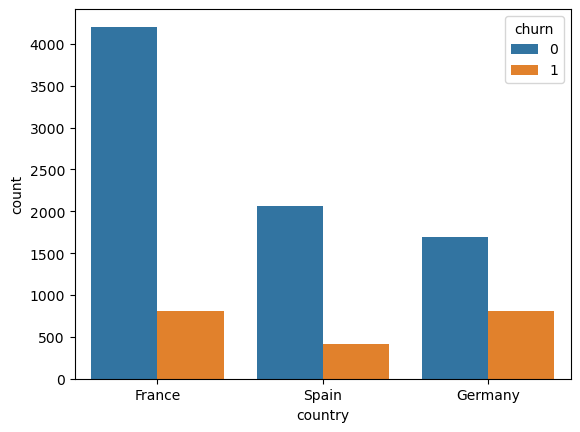

In [28]:
sns.countplot(x='country',hue='churn' , data=df)

In [29]:
pd.crosstab(df["country"], df["churn"], normalize="index")*100

churn,0,1
country,,
France,83.845233,16.154767
Germany,67.556796,32.443204
Spain,83.326605,16.673395


In [30]:

# Encode categorical columns
df = pd.get_dummies(df, columns=['country'], drop_first=True)

In [31]:
df

,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn,gender_Male,age_group_Adult,age_group_MidAge,age_group_Senior,country_Germany,country_Spain
0,619,42,2,0.00,1,1,1,101348.88,1,False,True,False,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,0,False,True,False,False,False,True
2,502,42,8,159660.80,3,1,0,113931.57,1,False,True,False,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,0,False,True,False,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,0,False,True,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,39,5,0.00,2,1,0,96270.64,0,True,True,False,False,False,False
9996,516,35,10,57369.61,1,1,1,101699.77,0,True,True,False,False,False,False
9997,709,36,7,0.00,1,0,1,42085.58,1,False,True,False,False,False,False
9998,772,42,3,75075.31,2,1,0,92888.52,1,True,True,False,False,True,False


In [32]:
df

,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn,gender_Male,age_group_Adult,age_group_MidAge,age_group_Senior,country_Germany,country_Spain
0,619,42,2,0.00,1,1,1,101348.88,1,False,True,False,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,0,False,True,False,False,False,True
2,502,42,8,159660.80,3,1,0,113931.57,1,False,True,False,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,0,False,True,False,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,0,False,True,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,39,5,0.00,2,1,0,96270.64,0,True,True,False,False,False,False
9996,516,35,10,57369.61,1,1,1,101699.77,0,True,True,False,False,False,False
9997,709,36,7,0.00,1,0,1,42085.58,1,False,True,False,False,False,False
9998,772,42,3,75075.31,2,1,0,92888.52,1,True,True,False,False,True,False


# Credit_card vs churn

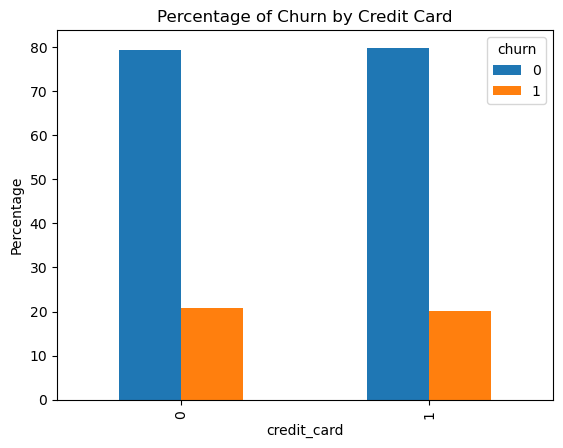

In [33]:
import pandas as pd

# Create percentage table
percent_data = pd.crosstab(df['credit_card'], df['churn'], normalize='index') * 100

# Plot
percent_data.plot(kind='bar')

plt.title("Percentage of Churn by Credit Card")
plt.ylabel("Percentage")
plt.show()

In [34]:
pd.crosstab(df['credit_card'], df['churn'], normalize='index')*100

churn,0,1
credit_card,,
0,79.185059,20.814941
1,79.815734,20.184266


# Active_member vs churn

<Axes: ylabel='active_member'>

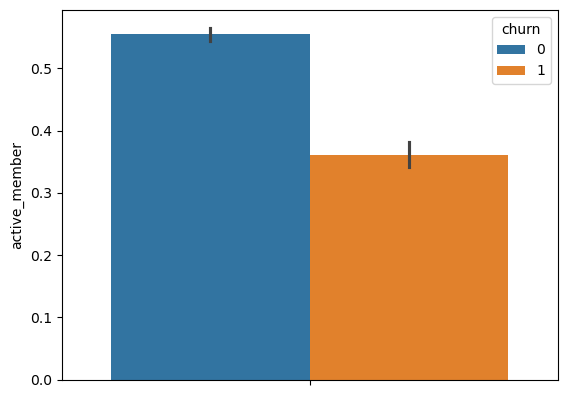

In [35]:
sns.barplot(y='active_member', hue='churn', data=df)

In [36]:
pd.crosstab(df['active_member'], df['churn'], normalize='index')*100

churn,0,1
active_member,,
0,73.149103,26.850897
1,85.730926,14.269074


<Axes: xlabel='active_member', ylabel='churn'>

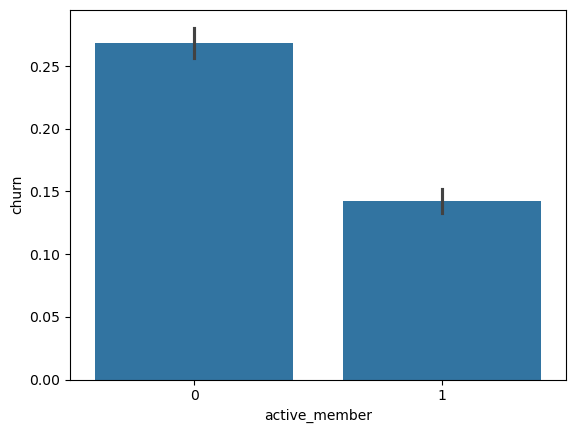

In [37]:
sns.barplot(x='active_member', y='churn', data=df) # 0 Inactive, 1-active

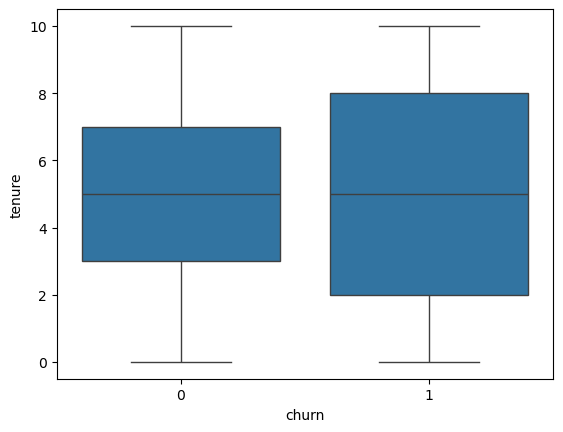

In [38]:

sns.boxplot(x='churn', y='tenure', data=df)
plt.show()

<Axes: xlabel='tenure', ylabel='count'>

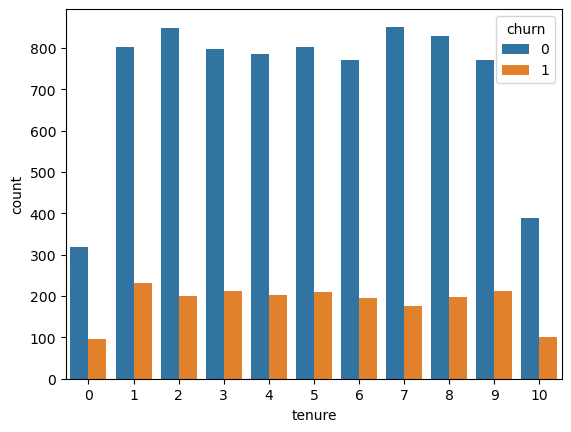

In [39]:
sns.countplot(x='tenure', hue='churn', data=df)

# Products Number vs churn

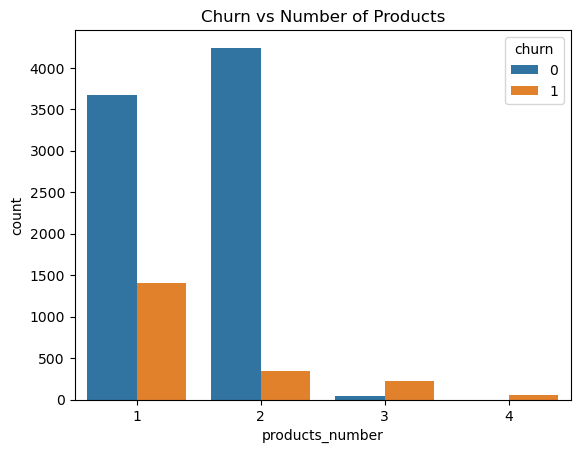

In [40]:
sns.countplot(x='products_number', hue='churn', data=df)
plt.title('Churn vs Number of Products')
plt.show()

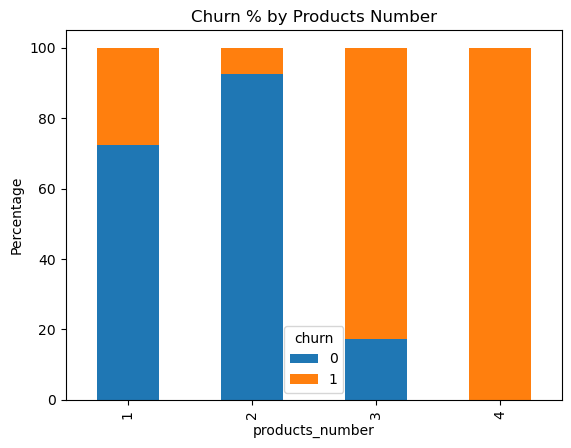

In [41]:
prod_churn = pd.crosstab(df['products_number'], df['churn'], normalize='index') * 100
prod_churn.plot(kind='bar', stacked=True)

plt.title('Churn % by Products Number')
plt.ylabel('Percentage')
plt.show()

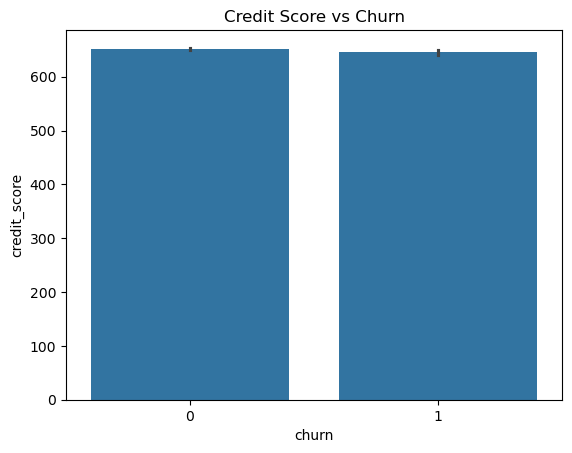

In [42]:
# credit_score

sns.barplot(x='churn', y='credit_score', data=df)
plt.title("Credit Score vs Churn")
plt.show()

In [43]:
df['balance_per_product'] = df['balance'] / (df['products_number'] + 1)

In [44]:
df['product_group'] = df['products_number'].apply(lambda x:
    'Low' if x == 1 else
    'Medium' if x == 2 else
    'High'
)

In [45]:
df

,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn,gender_Male,age_group_Adult,age_group_MidAge,age_group_Senior,country_Germany,country_Spain,balance_per_product,product_group
0,619,42,2,0.00,1,1,1,101348.88,1,False,True,False,False,False,False,0.000000,Low
1,608,41,1,83807.86,1,0,1,112542.58,0,False,True,False,False,False,True,41903.930000,Low
2,502,42,8,159660.80,3,1,0,113931.57,1,False,True,False,False,False,False,39915.200000,High
3,699,39,1,0.00,2,0,0,93826.63,0,False,True,False,False,False,False,0.000000,Medium
4,850,43,2,125510.82,1,1,1,79084.10,0,False,True,False,False,False,True,62755.410000,Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,39,5,0.00,2,1,0,96270.64,0,True,True,False,False,False,False,0.000000,Medium
9996,516,35,10,57369.61,1,1,1,101699.77,0,True,True,False,False,False,False,28684.805000,Low
9997,709,36,7,0.00,1,0,1,42085.58,1,False,True,False,False,False,False,0.000000,Low
9998,772,42,3,75075.31,2,1,0,92888.52,1,True,True,False,False,True,False,25025.103333,Medium


In [46]:
df_new = df.drop(['age_group_Adult','age_group_MidAge','age_group_Senior','product_group','estimated_salary','balance','credit_card'], axis=1)

In [47]:
df_new.astype(int)

,credit_score,age,tenure,products_number,active_member,churn,gender_Male,country_Germany,country_Spain,balance_per_product
0,619,42,2,1,1,1,0,0,0,0
1,608,41,1,1,1,0,0,0,1,41903
2,502,42,8,3,0,1,0,0,0,39915
3,699,39,1,2,0,0,0,0,0,0
4,850,43,2,1,1,0,0,0,1,62755
...,...,...,...,...,...,...,...,...,...,...
9995,771,39,5,2,0,0,1,0,0,0
9996,516,35,10,1,1,0,1,0,0,28684
9997,709,36,7,1,1,1,0,0,0,0
9998,772,42,3,2,0,1,1,1,0,25025


In [48]:
data = df_new.drop(columns=['churn'])
data

,credit_score,age,tenure,products_number,active_member,gender_Male,country_Germany,country_Spain,balance_per_product
0,619,42,2,1,1,False,False,False,0.000000
1,608,41,1,1,1,False,False,True,41903.930000
2,502,42,8,3,0,False,False,False,39915.200000
3,699,39,1,2,0,False,False,False,0.000000
4,850,43,2,1,1,False,False,True,62755.410000
...,...,...,...,...,...,...,...,...,...
9995,771,39,5,2,0,True,False,False,0.000000
9996,516,35,10,1,1,True,False,False,28684.805000
9997,709,36,7,1,1,False,False,False,0.000000
9998,772,42,3,2,0,True,True,False,25025.103333


In [49]:
num_cols = ['credit_score', 'age', 'tenure', 'balance_per_product']

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

data[num_cols] = scaler.fit_transform(data[num_cols])

In [50]:
data

,credit_score,age,tenure,products_number,active_member,gender_Male,country_Germany,country_Spain,balance_per_product
0,-0.326221,0.293517,-1.041760,1,1,False,False,False,-1.172322
1,-0.440036,0.198164,-1.387538,1,1,False,False,True,0.289569
2,-1.536794,0.293517,1.032908,3,0,False,False,False,0.220189
3,0.501521,0.007457,-1.387538,2,0,False,False,False,-1.172322
4,2.063884,0.388871,-1.041760,1,1,False,False,True,1.017009
...,...,...,...,...,...,...,...,...,...
9995,1.246488,0.007457,-0.004426,2,0,True,False,False,-1.172322
9996,-1.391939,-0.373958,1.724464,1,1,True,False,False,-0.171603
9997,0.604988,-0.278604,0.687130,1,1,False,False,False,-1.172322
9998,1.256835,0.293517,-0.695982,2,0,True,True,False,-0.299278


In [51]:
data["balance_per_product"]

0      -1.172322
1       0.289569
2       0.220189
3      -1.172322
4       1.017009
          ...   
9995   -1.172322
9996   -0.171603
9997   -1.172322
9998   -0.299278
9999    1.097806
Name: balance_per_product, Length: 10000, dtype: float64

In [52]:
target=df_new['churn']
target

0       1
1       0
2       1
3       0
4       0
       ..
9995    0
9996    0
9997    1
9998    1
9999    0
Name: churn, Length: 10000, dtype: int64

In [53]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(data, target, test_size=0.2)

## RandomForestClassifier

In [54]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import accuracy_score

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=5,
    max_features='sqrt',
    random_state=42
)


rf.fit(X_train, y_train)
y_pred1=rf.predict(X_test)

print("Train:", rf.score(X_train, y_train))
print("Test:", rf.score(X_test,y_test))

Train: 0.88875
Test: 0.8575


In [55]:
accuracy_score(y_test, y_pred1)

0.8575

In [56]:
precision_score(y_test,y_pred1)

0.7950819672131147

In [57]:
recall_score(y_test,y_pred1)

0.4522144522144522

In [58]:
f1_score(y_test,y_pred1)

0.5765230312035661

## LogisticRegression

In [59]:
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression()
lr.fit(X_train, y_train)
print("Tran",lr.score(X_train, y_train))
y_pred2=lr.predict(X_test)
print("Test",lr.score(X_test, y_test))


Tran 0.815375
Test 0.8025


In [60]:
accuracy_score(y_test,y_pred2)

0.8025

In [61]:
precision_score(y_test,y_pred2)

0.6164383561643836

## svm

In [62]:
from sklearn import svm
svm = svm.SVC()
svm.fit(X_train,y_train)
y_pred3=svm.predict(X_test)

In [63]:
print("Train",svm.score(X_test, y_test))
print("Test",svm.score(X_test,y_test))

Train 0.8455
Test 0.8455


In [64]:
accuracy_score(y_test,y_pred3)

0.8455

In [65]:
precision_score(y_test,y_pred3)

0.8225806451612904

##  KNeighborsClassifier

In [66]:
from sklearn.neighbors import KNeighborsClassifier

In [67]:
knn = KNeighborsClassifier()

In [68]:
knn.fit(X_train,y_train)
y_pred4=knn.predict(X_test)

In [69]:
print("Train",knn.score(X_train,y_train))
print("Test",knn.score(X_test, y_test))


Train 0.881
Test 0.833


In [70]:
accuracy_score(y_test,y_pred4)

0.833

In [71]:
precision_score(y_test,y_pred4)

0.6923076923076923

## DecisionTreeClassifier

In [72]:
from sklearn.tree import DecisionTreeClassifier

In [73]:
dt = DecisionTreeClassifier()

In [74]:
dt.fit(X_train, y_train)
y_pred5=dt.predict(X_test)

In [75]:
print("Train",dt.score(X_train,y_train))
print("Test",dt.score(X_test,y_test))

Train 1.0
Test 0.7735


In [76]:
accuracy_score(y_test,y_pred5)

0.7735

In [77]:
precision_score(y_test,y_pred5)

0.47345132743362833

## GradientBoostingClassifier

In [78]:
from sklearn.ensemble import GradientBoostingClassifier

In [79]:
gbc = GradientBoostingClassifier()


In [80]:
gbc.fit(X_train, y_train)
y_pred6=gbc.predict(X_test)

In [81]:
print("Train",gbc.score(X_train,y_train))
print("Test",gbc.score(X_test,y_test))

Train 0.874875
Test 0.8565


In [82]:
accuracy_score(y_test,y_pred6)

0.8565

In [83]:
precision_score(y_test,y_pred6)

0.7795275590551181

## xgb

In [84]:
import xgboost as xgb

model_xgb = xgb.XGBClassifier(random_state=42, verbosity = 0)
model_xgb.fit(X_train, y_train)
y_pred7=model_xgb.predict(X_test)

In [85]:
print("Train",model_xgb.score(X_train,y_train))
print("Test",model_xgb.score(X_test,y_test))

Train 0.941
Test 0.8515


In [86]:
accuracy_score(y_test,y_pred7)

0.8515

In [87]:
precision_score(y_test,y_pred7)

0.7323943661971831

In [88]:
recall_score(y_test,y_pred7)

0.48484848484848486

In [89]:
performance_summary = pd.DataFrame({
    'Model':['RF','LR','SVM','KNN','DT','GBC','XGB'],
    'ACC':[accuracy_score(y_test,y_pred1),
           accuracy_score(y_test,y_pred2),
           accuracy_score(y_test,y_pred3),
           accuracy_score(y_test,y_pred4),
           accuracy_score(y_test,y_pred5),
           accuracy_score(y_test,y_pred6),
           accuracy_score(y_test,y_pred7)
          ]
})

In [90]:

performance_summary

,Model,ACC
0,RF,0.8575
1,LR,0.8025
2,SVM,0.8455
3,KNN,0.8330
4,DT,0.7735
5,GBC,0.8565
6,XGB,0.8515


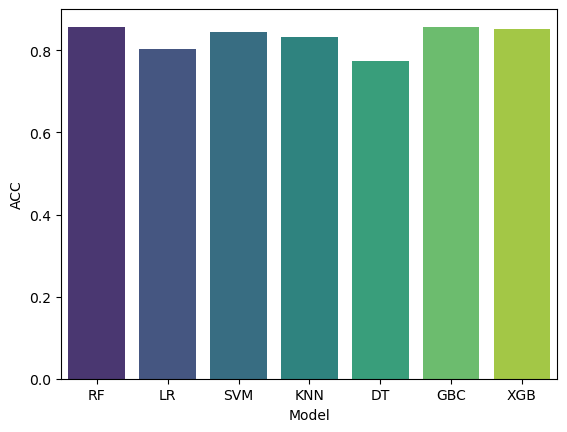

In [91]:
sns.barplot(
    data=performance_summary,
    x='Model',
    y='ACC',
    hue='Model',
    palette='viridis',
    legend=False
)
plt.show()

### I can see best performance is GBC with high accuracy

In [92]:
performance_summary = pd.DataFrame({
    'Model':['RF','LR','SVM','KNN','DT','GBC','XGB'],
    'PRECISION':[precision_score(y_test,y_pred1),
           precision_score(y_test,y_pred2),
           precision_score(y_test,y_pred3),
           precision_score(y_test,y_pred4),
           precision_score(y_test,y_pred5),
           precision_score(y_test,y_pred6),
            precision_score(y_test,y_pred6)
          ]
})


In [93]:
performance_summary

,Model,PRECISION
0,RF,0.795082
1,LR,0.616438
2,SVM,0.822581
3,KNN,0.692308
4,DT,0.473451
5,GBC,0.779528
6,XGB,0.779528


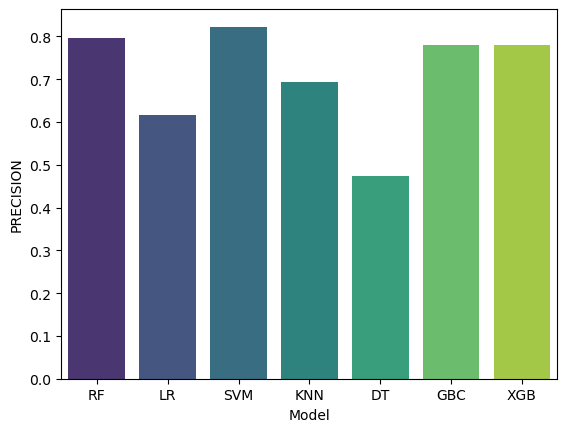

In [94]:
sns.barplot(
    data=performance_summary,
    x='Model',
    y='PRECISION',
    hue='Model',
    palette='viridis',
    legend=False
)
plt.show()

### Best precision is svm 

In [95]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

performance_summary = pd.DataFrame({
    'Model':['RF','LR','SVM','KNN','DT','GBC','XGB'],
    'Recall':[recall_score(y_test,y_pred1),
              recall_score(y_test,y_pred2),
              recall_score(y_test,y_pred3),
              recall_score(y_test,y_pred4),
              recall_score(y_test,y_pred5),
              recall_score(y_test,y_pred6),
              recall_score(y_test,y_pred7)],
    'F1':[f1_score(y_test,y_pred1),
          f1_score(y_test,y_pred2),
          f1_score(y_test,y_pred3),
          f1_score(y_test,y_pred4),
          f1_score(y_test,y_pred5),
          f1_score(y_test,y_pred6),
          f1_score(y_test,y_pred7)]
})

In [96]:
performance_summary

,Model,Recall,F1
0,RF,0.452214,0.576523
1,LR,0.209790,0.313043
2,SVM,0.356643,0.497561
3,KNN,0.398601,0.505917
4,DT,0.498834,0.485812
5,GBC,0.461538,0.579795
6,XGB,0.484848,0.583450


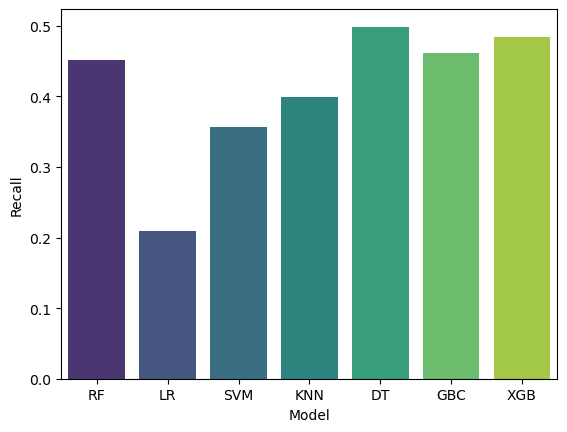

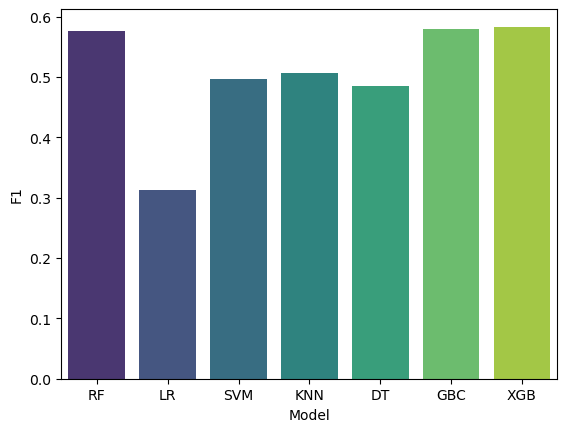

In [97]:
sns.barplot(
    data=performance_summary,
    x='Model',
    y='Recall',
    hue='Model',
    palette='viridis',
    legend=False
)
plt.show()
sns.barplot(
    data=performance_summary,
    x='Model',
    y='F1',
    hue='Model',
    palette='viridis',
    legend=False
)
plt.show()

# Hypertuning test Find best model using GridSearchCV

In [98]:
from sklearn.svm import SVC

svm = SVC(probability=True)


In [99]:
from sklearn.ensemble import VotingClassifier

voting_model = VotingClassifier(
    estimators=[
        ('svm', svm),
        ('gbc', gbc),
        ('xgb', model_xgb)
    ],
    voting='soft'
)

In [100]:
voting_model.fit(X_train, y_train)

,estimators,"[('svm', ...), ('gbc', ...), ...]"
,voting,'soft'
,weights,None
,n_jobs,None
,flatten_transform,True
,verbose,False
,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0


In [101]:

y_pred_voting = voting_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_voting))
print("Precision:", precision_score(y_test, y_pred_voting))
print("Recall:", recall_score(y_test, y_pred_voting))
print("F1 Score:", f1_score(y_test, y_pred_voting))

Accuracy: 0.859
Precision: 0.810126582278481
Recall: 0.44755244755244755
F1 Score: 0.5765765765765766


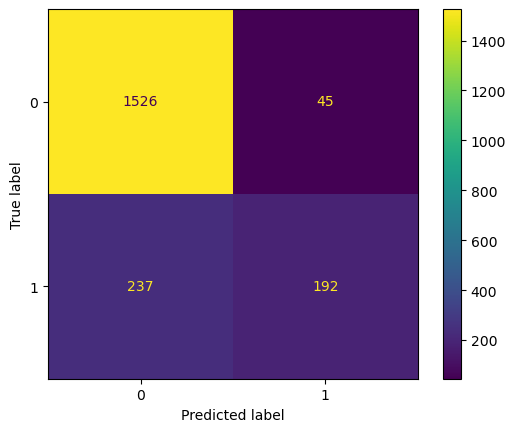

In [106]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(voting_model, X_test, y_test)

In [103]:
new_customer = [[
    750,   # credit_score (high ✅)
    30,    # age (younger-middle ✅)
    7,     # tenure (loyal customer ✅)
    2,     # products_number (normal ✅)
    1,     # active_member (very important ✅)
    1,     # gender_Male
    0,     # Germany
    0,     # Spain (so France/other default)
    1000   # balance_per_product (moderate ✅)
]]

prediction =voting_model.predict(new_customer)
print("Prediction:", prediction)

Prediction: [0]


C:\Users\lucky\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
C:\Users\lucky\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but GradientBoostingClassifier was fitted with feature names
  warnings.warn(


# Test the model for few properties